# 03 - Data Preprocessing & Interaction Cleaning

**Project:** GroundedNutriRec  
**Scope:** Preprocess and clean the Food.com user-recipe interactions dataset to make it suitable for baseline and advanced recommender models.  
**Objectives:**
1. Load user-recipe interaction records (`RAW_interactions.csv`).
2. Remove duplicate interactions (multiple reviews by the same user on the same recipe).
3. Handle missing ratings and identify rating-0 records (implicit interactions).
4. Normalize explicit ratings using user-mean subtraction (centering).
5. Apply iterative K-Core filtering (e.g. $K=5$) to reduce sparsity and filter out cold-start entities.
6. Derive implicit feedback labels (`liked = 1` for high ratings, `0` for low ratings).
7. Save the preprocessed dataset as `interactions_clean.csv`.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

interactions_path = Path("dataset/archive_3/RAW_interactions.csv")
output_path = Path("dataset/archive_3/interactions_clean.csv")

print(f"Source data: {interactions_path}")
print(f"Output destination: {output_path}")

Source data: dataset\archive_3\RAW_interactions.csv
Output destination: dataset\archive_3\interactions_clean.csv


## 2. Load Dataset

In [2]:
print("Loading dataset...")
df = pd.read_csv(interactions_path)
print(f"Original dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Missing values in columns:\n{df.isnull().sum()}")
df.head()

Loading dataset...


Original dataset shape: (1132367, 5)
Columns: ['user_id', 'recipe_id', 'date', 'rating', 'review']
Missing values in columns:
user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


## 3. Step 1: Remove Duplicate Interactions

A duplicate interaction occurs when a user has rated the same recipe multiple times. For standard collaborative filtering, we need unique user-item pairs.

In [3]:
duplicates_count = df.duplicated(subset=["user_id", "recipe_id"]).sum()
print(f"Number of duplicate (user_id, recipe_id) interactions: {duplicates_count}")

# Drop duplicates and keep the last one (assuming latest date)
df_dedup = df.drop_duplicates(subset=["user_id", "recipe_id"], keep="last").reset_index(drop=True)
print(f"Dataset shape after duplicate removal: {df_dedup.shape}")

Number of duplicate (user_id, recipe_id) interactions: 0
Dataset shape after duplicate removal: (1132367, 5)


## 4. Step 2: Handle Missing and Zero Ratings

In Food.com, a rating of `0` denotes that the user interacted (reviewed/commented) but did not leave a numerical star rating. We need to count these implicit interactions.

In [4]:
print(f"Null ratings: {df_dedup['rating'].isnull().sum()}")
zero_ratings = (df_dedup['rating'] == 0).sum()
print(f"Rating = 0 (implicit reviews) count: {zero_ratings} ({zero_ratings / len(df_dedup) * 100:.2f}% of data)")

Null ratings: 0
Rating = 0 (implicit reviews) count: 60847 (5.37% of data)


## 5. Step 3: Normalize Ratings

To adjust for user rating biases (e.g., some users rate harshly, others generously), we apply user-mean centering to positive (explicit) ratings.

In [5]:
# Center explicit ratings (>0) per user
user_means = df_dedup[df_dedup['rating'] > 0].groupby('user_id')['rating'].mean()
global_mean = df_dedup[df_dedup['rating'] > 0]['rating'].mean()

df_dedup['user_mean_rating'] = df_dedup['user_id'].map(user_means).fillna(global_mean)

# Centered rating: positive ratings centered around the user's mean, implicit ratings kept as NaN/0
df_dedup['normalized_rating'] = np.where(
    df_dedup['rating'] > 0, 
    df_dedup['rating'] - df_dedup['user_mean_rating'], 
    np.nan
)

print(f"Global explicit rating mean: {global_mean:.4f}")
print("Sample centered ratings:")
display(df_dedup[['user_id', 'recipe_id', 'rating', 'user_mean_rating', 'normalized_rating']].head())

Global explicit rating mean: 4.6615
Sample centered ratings:


,user_id,recipe_id,rating,user_mean_rating,normalized_rating
0,38094,40893,4,4.828571,-0.828571
1,1293707,40893,5,4.913043,0.086957
2,8937,44394,4,4.225806,-0.225806
3,126440,85009,5,4.848016,0.151984
4,57222,85009,5,4.548837,0.451163


## 6. Step 4: K-Core Filtering

Collaborative filtering suffers from cold-start and extreme sparsity. We iteratively keep only users with $\ge 5$ interactions and recipes with $\ge 5$ ratings.

In [6]:
k = 5
df_kcore = df_dedup.copy()
iteration = 0

print(f"Starting shape: {df_kcore.shape}")
while True:
    user_counts = df_kcore['user_id'].value_counts()
    recipe_counts = df_kcore['recipe_id'].value_counts()
    
    active_users = user_counts[user_counts >= k].index
    active_recipes = recipe_counts[recipe_counts >= k].index
    
    filtered = df_kcore[df_kcore['user_id'].isin(active_users) & df_kcore['recipe_id'].isin(active_recipes)]
    if len(filtered) == len(df_kcore):
        break
    df_kcore = filtered.reset_index(drop=True)
    iteration += 1
    print(f"Iteration {iteration}: Shape is {df_kcore.shape}")

print(f"\nFinal K-Core filtered shape: {df_kcore.shape}")
print(f"Unique users: {df_kcore['user_id'].nunique()}, Unique recipes: {df_kcore['recipe_id'].nunique()}")
sparsity = (1 - (len(df_kcore) / (df_kcore['user_id'].nunique() * df_kcore['recipe_id'].nunique()))) * 100
print(f"Sparsity of K-Core filtered dataset: {sparsity:.4f}%")

Starting shape: (1132367, 7)


Iteration 1: Shape is (611544, 7)


Iteration 2: Shape is (565002, 7)


Iteration 3: Shape is (557457, 7)


Iteration 4: Shape is (555986, 7)
Iteration 5: Shape is (555706, 7)


Iteration 6: Shape is (555654, 7)


Iteration 7: Shape is (555634, 7)
Iteration 8: Shape is (555626, 7)


Iteration 9: Shape is (555622, 7)


Iteration 10: Shape is (555618, 7)

Final K-Core filtered shape: (555618, 7)
Unique users: 17813, Unique recipes: 41240
Sparsity of K-Core filtered dataset: 99.9244%


## 7. Step 5: Create Implicit Feedback Label

Convert explicit ratings into binary labels:  
- `liked = 1` if `rating >= 4`  
- `liked = 0` if `0 < rating < 4`  
- `liked = NaN` if `rating == 0` (no explicit rating given)

In [7]:
df_kcore['liked'] = np.where(
    df_kcore['rating'] == 0,
    np.nan,
    np.where(df_kcore['rating'] >= 4, 1.0, 0.0)
)

print("Implicit feedback count distribution:")
print(df_kcore['liked'].value_counts(dropna=False))
df_kcore.head()

Implicit feedback count distribution:
liked
1.0    517549
0.0     24997
NaN     13072
Name: count, dtype: int64


,user_id,recipe_id,date,rating,review,user_mean_rating,normalized_rating,liked
0,202555,225241,2007-06-20,5,My husband has just found out that he had to c...,4.731707,0.268293,1.0
1,353579,225241,2007-08-14,5,"Very good, made with ingredients I usually hav...",4.771987,0.228013,1.0
2,681408,225241,2008-03-14,0,This is a very good recipe. We also want to c...,5.000000,NaN,NaN
3,684460,225241,2009-01-18,5,We really liked this recipe - something differ...,5.000000,0.000000,1.0
4,900992,225241,2009-02-19,3,"The ""cornbread"" on top is bland. I'd us a real...",3.857482,-0.857482,0.0


## 8. Visualizations

Let's visualize the distribution of ratings and user mean ratings in the preprocessed dataset.

C:\Users\krina\AppData\Local\Temp\ipykernel_16256\3702248569.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_kcore, x='rating', palette='viridis', ax=axes[0])


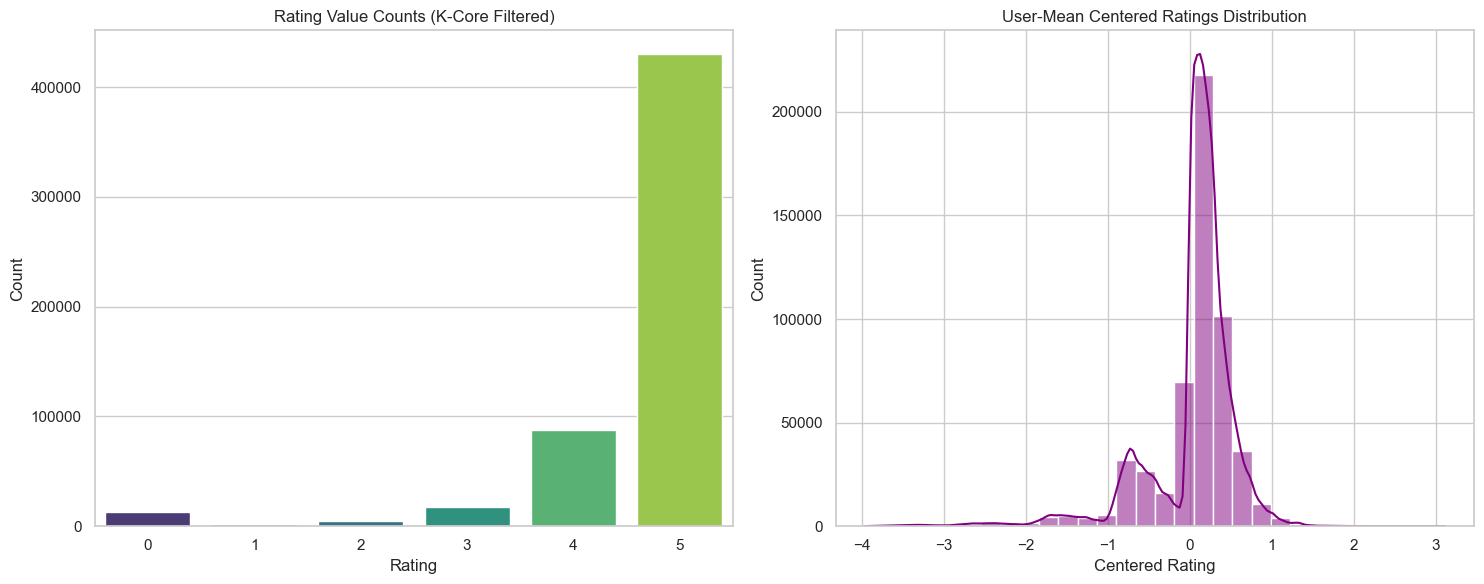

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Rating counts distribution
sns.countplot(data=df_kcore, x='rating', palette='viridis', ax=axes[0])
axes[0].set_title('Rating Value Counts (K-Core Filtered)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Normalized ratings distribution
sns.histplot(df_kcore['normalized_rating'].dropna(), bins=30, kde=True, ax=axes[1], color='purple')
axes[1].set_title('User-Mean Centered Ratings Distribution')
axes[1].set_xlabel('Centered Rating')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 9. Save Preprocessed Dataset

We save the clean, filtered interaction dataset to the `dataset/archive_3/` directory.

In [9]:
output_path.parent.mkdir(parents=True, exist_ok=True)
df_kcore.to_csv(output_path, index=False)
print(f"Cleaned dataset saved successfully to {output_path}!")

Cleaned dataset saved successfully to dataset\archive_3\interactions_clean.csv!
